<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/lab11_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ch 7: Unsupervised Learning

In [ ]:
from random import choices,seed
numberofrolls=1800
seed(9)
dice1=choices([1,2,3,4,5,6], k=numberofrolls)
dice2=choices([1,2,3,4,5,6], k=numberofrolls)

In [ ]:
print(dice1[0:10])

[3, 3, 1, 6, 1, 4, 6, 1, 4, 4]


In [ ]:
dicesum=[dice1[n]+dice2[n] for n in range(numberofrolls)]

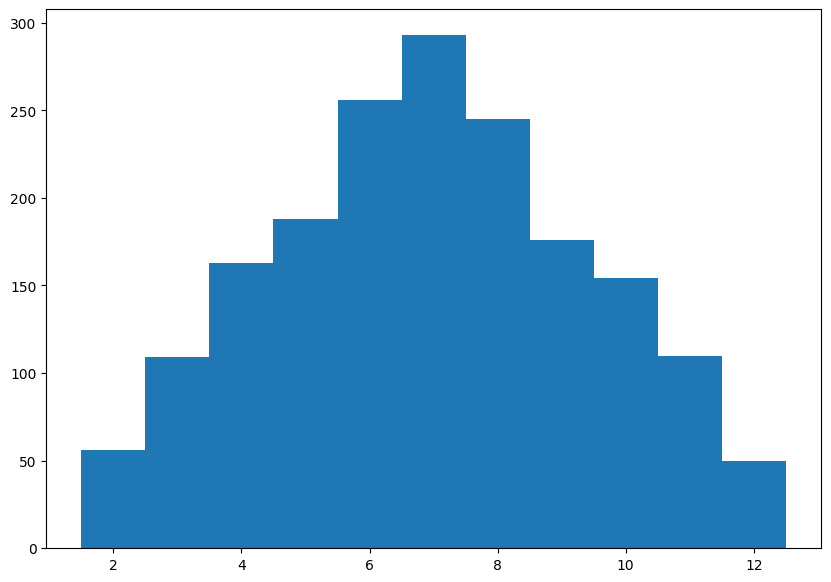

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(dicesum,bins=[2,3,4,5,6,7,8,9,10,11,12,13],align='left')
plt.show()

In [ ]:
def getcenter(allpoints):
    center=np.mean(allpoints)
    stdev=np.sqrt(np.cov(allpoints))
    return(center,stdev)
print(getcenter(dicesum))

(np.float64(6.9511111111111115), np.float64(2.468219092930105))


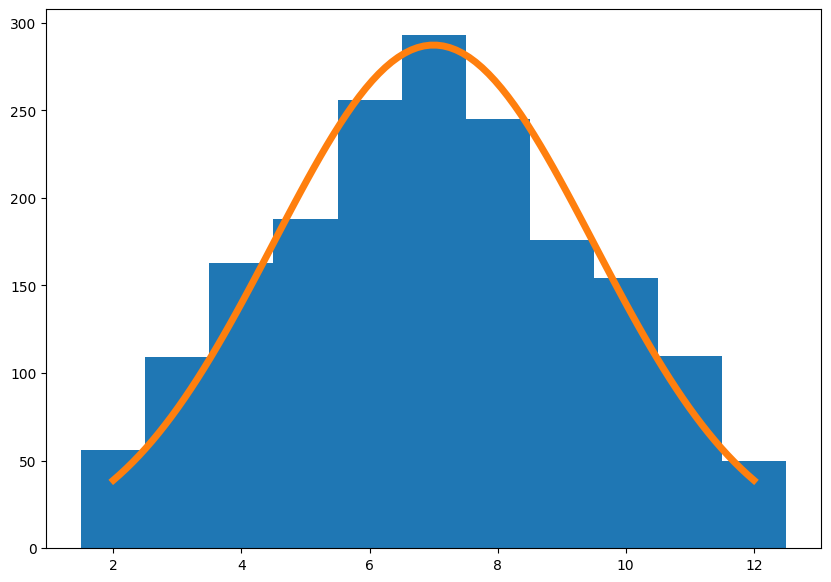

In [ ]:
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(dicesum,bins=range(2,14),align='left')
import scipy.stats as stats
import math
mu=7
sigma=2.5
x = np.linspace(mu - 2*sigma, mu + 2*sigma, 100)*1
plt.plot(x, stats.norm.pdf(x, mu, sigma)*numberofrolls,linewidth=5)
plt.show()

In [ ]:
print( stats.norm.pdf(2, mu, sigma)*numberofrolls )
print( stats.norm.pdf(7, mu, sigma)*numberofrolls )
print( stats.norm.pdf(12, mu, sigma)*numberofrolls )

38.8734958894954
287.23844188903155
38.8734958894954


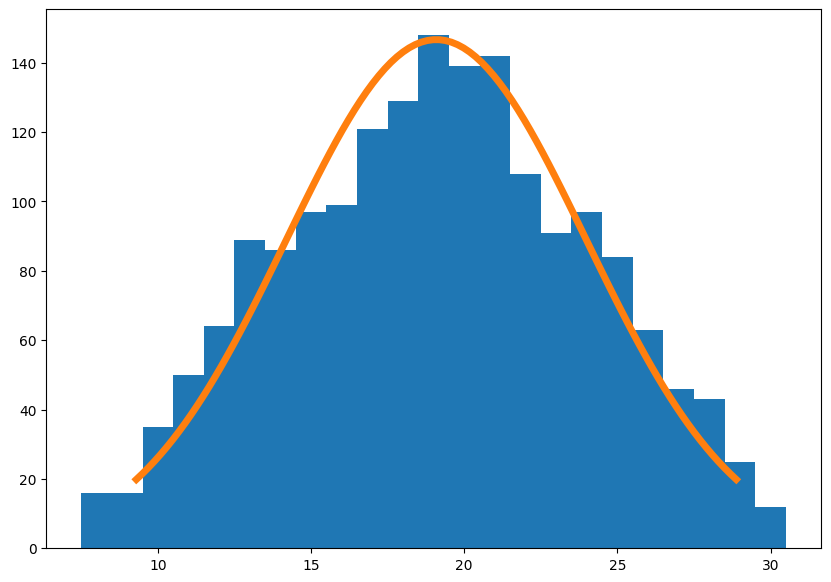

In [ ]:
seed(913)
dice1=choices([4,5,6,7,8,9,10,11,12,13,14,15], k=numberofrolls)
dice2=choices([4,5,6,7,8,9,10,11,12,13,14,15], k=numberofrolls)
dicesum12=[dice1[n]+dice2[n] for n in range(numberofrolls)]
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(dicesum12,bins=range(8,32),align='left')
mu=np.mean(dicesum12)
sigma=np.std(dicesum12)
x = np.linspace(mu - 2*sigma, mu + 2*sigma, 100)*1
plt.plot(x, stats.norm.pdf(x, mu, sigma)*numberofrolls,linewidth=5)
plt.show()

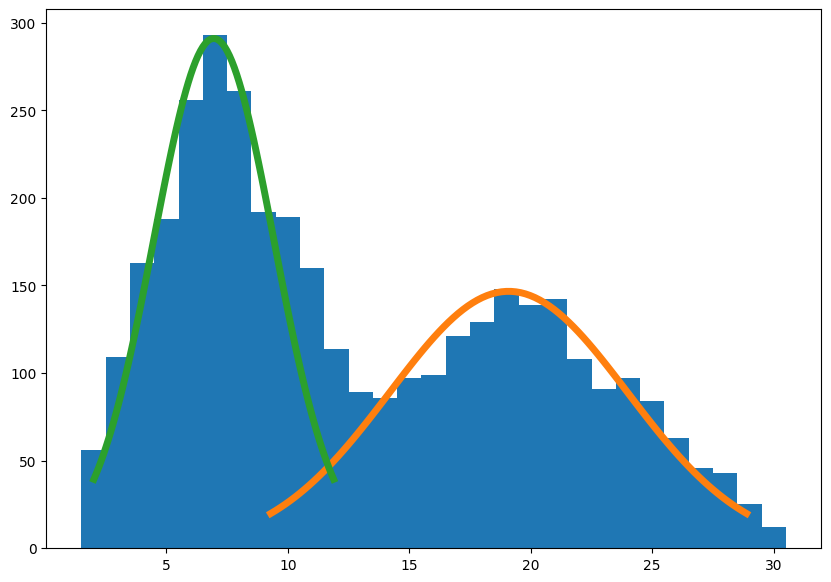

In [ ]:
dicesumboth=dicesum+dicesum12
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(dicesumboth,bins=range(2,32),align='left')
import scipy.stats as stats
import math
mu=np.mean(dicesum12)
sigma=np.std(dicesum12)
x = np.linspace(mu - 2*sigma, mu + 2*sigma, 100)*1
plt.plot(x, stats.norm.pdf(x, mu, sigma)*numberofrolls,linewidth=5)
mu=np.mean(dicesum)
sigma=np.std(dicesum)
x = np.linspace(mu - 2*sigma, mu + 2*sigma, 100)*1
plt.plot(x, stats.norm.pdf(x, mu, sigma)*numberofrolls,linewidth=5)
plt.show()

In [ ]:
seed(494)
randomselection=choices(dicesumboth, k=1)
print(randomselection)

[12]


In [ ]:
print( stats.norm.pdf(8, np.mean(dicesum), np.std(dicesum))*numberofrolls )
print( stats.norm.pdf(8, np.mean(dicesum12), np.std(dicesum12))*numberofrolls )

265.87855493973007
11.289203035758725


In [ ]:
print( stats.norm.pdf(12, np.mean(dicesum), np.std(dicesum))*numberofrolls)
print( stats.norm.pdf(12, np.mean(dicesum12), np.std(dicesum12))*numberofrolls )

35.87586208537935
51.42993240324318


In [ ]:
from scipy.stats import multivariate_normal
def classify(allpts,allmns,allvar):
    vars=[]
    for n in range(len(allmns)):
        vars.append(multivariate_normal(mean=allmns[n], cov=allvar[n]))
    classification=[]
    for point in allpts:
        this_classification=-1
        this_pdf=0
        for n in range(len(allmns)):
            if vars[n].pdf(point)>this_pdf:
                this_pdf=vars[n].pdf(point)
                this_classification=n+1
        classification.append(this_classification)
    return classification

In [ ]:
allpoints = [2,8,12,15,25]
allmeans = [7, 19]
allvar = [np.cov(dicesum),np.cov(dicesum12)]
print(classify(allpoints,allmeans,allvar))

[1, 1, 2, 2, 2]


In [ ]:
import ast
import requests
link = "https://bradfordtuckfield.com/emdata.txt"
f = requests.get(link)
allpoints = ast.literal_eval(f.text)

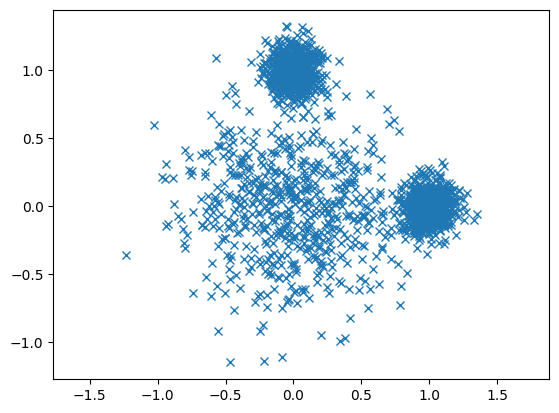

In [ ]:
allxs=[point[0] for point in allpoints]
allys=[point[1] for point in allpoints]
plt.plot(allxs, allys, 'x')
plt.axis('equal')
plt.show()

In [ ]:
mean1=[-1,0]
mean2=[0.5,-1]
mean3=[0.5,0.5]
allmeans=[mean1,mean2,mean3]
cov1=[[1,0],[0,1]]
cov2=[[1,0],[0,1]]
cov3=[[1,0],[0,1]]
allvar=[cov1,cov2,cov3]

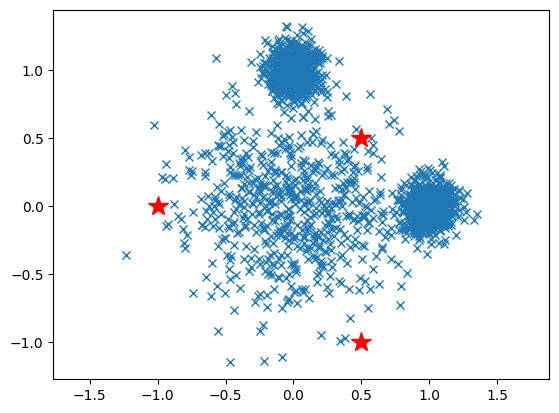

In [ ]:
plt.plot(allxs, allys, 'x')
plt.plot(mean1[0],mean1[1],'r*', markersize=15)
plt.plot(mean2[0],mean2[1],'r*', markersize=15)
plt.plot(mean3[0],mean3[1],'r*', markersize=15)
plt.axis('equal')
plt.show()

In [ ]:
def classify(allpts,allmns,allvar):
    vars=[]
    for n in range(len(allmns)):
        vars.append(multivariate_normal(mean=allmns[n], cov=allvar[n]))
    classification=[]
    for point in allpts:
        this_classification=-1
        this_pdf=0
        for n in range(len(allmns)):
            if vars[n].pdf(point)>this_pdf:
                this_pdf=vars[n].pdf(point)
                this_classification=n+1
        classification.append(this_classification)
    return classification

In [ ]:
theclass=classify(allpoints,allmeans,allvar)
print(theclass[:10])

[1, 1, 1, 1, 3, 1, 3, 3, 1, 3]


In [ ]:
def makeplot(allpoints,theclass,allmeans):
    thecolors=['black']*len(allpoints)
    for idx in range(len(thecolors)):
        if theclass[idx]==2:
            thecolors[idx]='green'
        if theclass[idx]==3:
            thecolors[idx]='yellow'
    allxs=[point[0] for point in allpoints]
    allys=[point[1] for point in allpoints]
    for i in range(len(allpoints)):
        plt.scatter(allxs[i], allys[i],color=thecolors[i])
    for i in range(len(allmeans)):
        plt.plot(allmeans[i][0],allmeans[i][1],'b*', markersize=15)
    plt.axis('equal')
    plt.show()

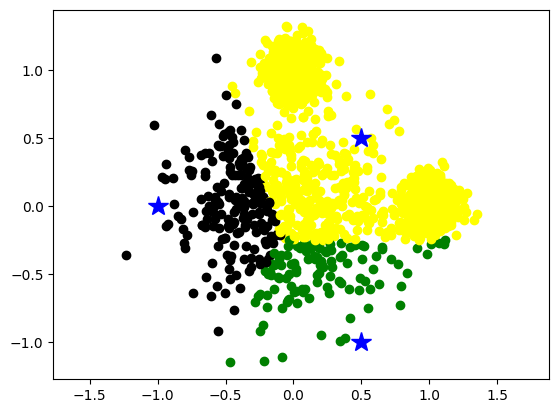

In [ ]:
makeplot(allpoints,theclass,allmeans)

In [ ]:
def getcenters(allpoints,theclass,k):
    centers=[]
    thevars=[]
    for n in range(k):
        pointsn=[allpoints[i] for i in range(0,len(allpoints)) if theclass[i]==(n+1)]
        xpointsn=[points[0] for points in pointsn]
        ypointsn=[points[1] for points in pointsn]
        xcenter=np.mean(xpointsn)
        ycenter=np.mean(ypointsn)
        centers.append([xcenter,ycenter])
        thevars.append(np.cov(xpointsn,ypointsn))
    return centers,thevars

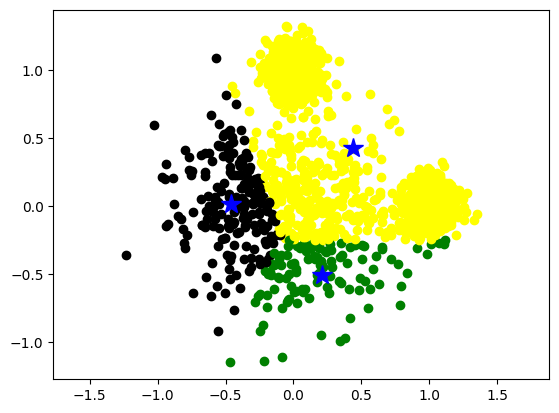

In [ ]:
allmeans,allvar=getcenters(allpoints,theclass,3)
makeplot(allpoints,theclass,allmeans)

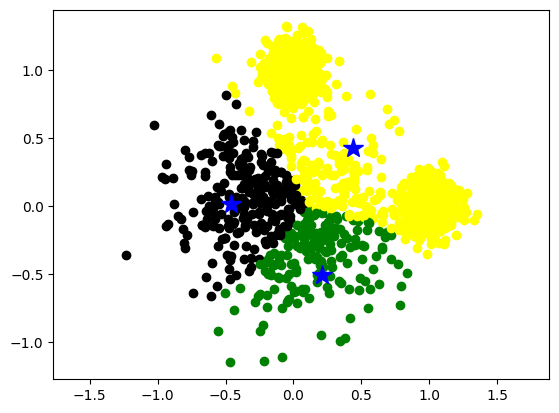

In [ ]:
theclass=classify(allpoints,allmeans,allvar)
makeplot(allpoints,theclass,allmeans)

In [ ]:
for n in range(0,100):
    theclass=classify(allpoints,allmeans,allvar)
    allmeans,allvar=getcenters(allpoints,theclass,3)
makeplot(allpoints, theclass,allmeans)

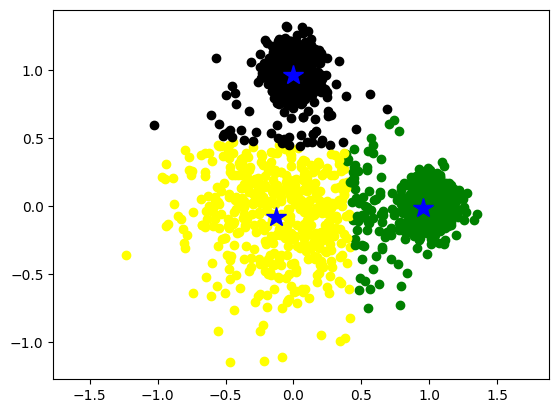

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(init="random", n_clusters=3, n_init=10, max_iter=300, random_state=42)
kmeans.fit(allpoints)
newclass=[label+1 for label in kmeans.labels_]
makeplot(allpoints,newclass,kmeans.cluster_centers_)

Unsupervised Learning:


The chapter begins with a definition of unsupervised learning in relation to supervised learning. Unsupervised learning is when an algorithm takes variables/feature from the dataset and creates a model of the features after finding relationships and natural groupings within the data.


After a brief rationale, the book moves on to generating an original dataset through randomizing 1800 rolls of two dice. The data we want to look at is actually the sum of each roll of the die. We plot the frequencies of the the sums to get a roughly bell curve/normally distributed shape. After calculating the mean and standard deviation of our sums, we plot an actual bell curve regression lines over our binned sums, also known as the normal probability density function.


We then repeat the previous section except with 12 sided dice. This results in a plot that even better fits the bell curve than the previous one. We plot them side by side on a bimodal histogram to see the difference in their distributions.


For the next part of the chapter, we are looking to predict whether a given sum from the combined set of our first and second sets of die rolls came from set one or two. We can, of course, intuit which set it came from by looking at the height of each bin for the given sum. However, the purpose of this exercise is to use an unsupervised tactic (clustering) to do the predicting. We create a classify function that uses the multivariate_normal() function to accomplish the goal of finding the highest bell curve.

Clustering methods have broad business applications especially when it comes to isolated consumer groups by demographics or tastes. Predating clustering and data science, segmentation uses intuition to separate large groups. However, data science gives us an advantage and helps us work in multiple dimensions. When we say dimension we refer to "any measurement that can vary between low and high" (154). Bivariate bell curves result from a probability distribution for a multi-variate outcome set.

Next, the chapter moves on to E-M clustering. We use an external dataset, as in previous chapters, and transmit the information into a list of points from a string. We immediately plot the data and notice some clusters. The technique we are using, E-M stands for expectation-maximization, essentially guesses the means/covariances of each cluster, classifies each datapoint according to which cluster it's most likely to be in, and calculates new estimates for the means/covariances of the clusters. These steps repeat until we decide that we have gotten a good stopping point for estimation.

We run through the E-M process for the random dataset we just examined. First, we make manual guesses for the means and covariances of the three clusters we are looking at. For convenience's sake, we use the identity matrix. We plot our guesses to see that they are not very accurate at all. We then use our existing classify() function to execute the next step. After classifying the datapoints, we plot the points and our clusters in a two-dimensional model that we should interpret as a set of 3-D bivariate curves. The stars of what should be the centers of the clusters are not as close to center as we would like. Therefore, we move onto the maximization step with an updated version of our getcenters() function and re-running the classify function. Finally, we get to the convergence step and run the classify and getcenters through a for loop cut off at 100 iterations. We then print out the final version of the plot and see that the stars are in what appears to be the dead centers of three clusters.

The book goes on to explain different clustering methods such as k-means clustering, which we can accomplish through only minor changes to our E-M clustering method. The classification step changes to classifying each datapoint by which cluster it should be a member of, according to the closest mean. After importing a KMeans package from Python, we plot our new estimation and find that the result is similar to the one we got from the E-M method except for the fact that the cluster sizes/densities are a little different.

The next clustering method mentioned in the chapter is density-based spatial clustering of applications with noise (DBSCAN) which is an expert in detecting unusually shaped data, such as spiral-shaped datapoints. The text also mentions hierarchial clustering, where the data is organized in nested groups.

The chapter ends by mentioning that there are other unsupervised learning techniques other than clustering ones: anomaly detection and latent variable models.